In [2]:
import os, json, time, random
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix
import albumentations as A
from transformers import Dinov2Model

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

SPLITS_PATH = "/kaggle/input/notebooks/sumaiyahoque/nb-04-partb-data-prep/splits"
NUM_CLASSES, MASK_THRESHOLD = 2, 127
IMAGENET_MEAN, IMAGENET_STD = np.array([0.485,0.456,0.406]), np.array([0.229,0.224,0.225])

IMG_SIZE = 224

train_df = pd.read_csv(f"{SPLITS_PATH}/train_unlabelled.csv")  
val_df   = pd.read_csv(f"{SPLITS_PATH}/val_labelled_finetune.csv") 
test_df  = pd.read_csv(f"{SPLITS_PATH}/test_monitor_eval.csv")   
print(f"Train (unlabelled): {len(train_df)} | Val (labelled FT): {len(val_df)} | Test: {len(test_df)}")

FG_PCT = 0.08
class_weights = torch.tensor([1/(1-FG_PCT), 1/FG_PCT])
class_weights = (class_weights/class_weights.sum()*NUM_CLASSES).to(DEVICE)
ce_loss_fn = nn.CrossEntropyLoss(weight=class_weights)

FROZEN_ENCODER = False  

Device: cuda
Train (unlabelled): 1035 | Val (labelled FT): 318 | Test: 168


networks ,head ,centering

In [3]:
student = Dinov2Model.from_pretrained("facebook/dinov2-small").to(DEVICE)
teacher = Dinov2Model.from_pretrained("facebook/dinov2-small").to(DEVICE)
teacher.load_state_dict(student.state_dict())
for p in teacher.parameters(): p.requires_grad = False

class DINOHead(nn.Module):
    def __init__(self, in_dim=384, out_dim=8192):  
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim,2048), nn.GELU(), nn.Linear(2048,2048), nn.GELU(), nn.Linear(2048,out_dim))
    def forward(self, x): return self.net(x)

student_head = DINOHead().to(DEVICE)
teacher_head = DINOHead().to(DEVICE)
teacher_head.load_state_dict(student_head.state_dict())
for p in teacher_head.parameters(): p.requires_grad = False

center = torch.zeros(1, 8192).to(DEVICE)
TEACHER_TEMP, STUDENT_TEMP, CENTER_MOMENTUM = 0.04, 0.1, 0.9

def dino_loss(student_out, teacher_out):
    global center
    t = F.softmax((teacher_out - center) / TEACHER_TEMP, dim=-1).detach() 
    s = F.log_softmax(student_out / STUDENT_TEMP, dim=-1)                  
    loss = -(t * s).sum(dim=-1).mean()
    center = CENTER_MOMENTUM * center + (1-CENTER_MOMENTUM) * teacher_out.mean(0, keepdim=True).detach()
    return loss

@torch.no_grad()
def ema_update(online, target, decay=0.996):
    for po, pt in zip(online.parameters(), target.parameters()):
        pt.data = decay * pt.data + (1 - decay) * po.data

PRETRAIN_CONFIG = {"method":"DINOv2","backbone":"ViT-S/14 (facebook/dinov2-small)","epochs":50,
                    "batch_size":16,"n_global_crops":2,"n_local_crops":4,"ema_decay":0.996,
                    "teacher_temp":TEACHER_TEMP,"student_temp":STUDENT_TEMP}
print(json.dumps(PRETRAIN_CONFIG, indent=2))

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

{
  "method": "DINOv2",
  "backbone": "ViT-S/14 (facebook/dinov2-small)",
  "epochs": 50,
  "batch_size": 16,
  "n_global_crops": 2,
  "n_local_crops": 4,
  "ema_decay": 0.996,
  "teacher_temp": 0.04,
  "student_temp": 0.1
}


50 epoch pretraning 

In [4]:
class MultiCropDataset(Dataset):
    """DINOv2 multi-crop: 2 global 224x224 crops + 4 local 96x96 crops."""
    def __init__(self, df):
        self.paths = df["img_path"].tolist()
        self.global_t = A.Compose([
            A.RandomResizedCrop(size=(224, 224), scale=(0.4, 1.0)),
            A.HorizontalFlip(p=0.5)
        ])
        self.local_t = A.Compose([
            A.RandomResizedCrop(size=(96, 96), scale=(0.05, 0.4)),
            A.HorizontalFlip(p=0.5)
        ])
    def __len__(self):
        return len(self.paths)
    def _norm(self, v):
        v = v.astype(np.float32) / 255.0
        v = (v - np.array(IMAGENET_MEAN, dtype=np.float32)) / np.array(IMAGENET_STD, dtype=np.float32)
        return torch.from_numpy(v.transpose(2, 0, 1)).float()
    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx])
        if img is None:
            raise FileNotFoundError(f"Could not read image: {self.paths[idx]}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        globals_ = [
            self._norm(self.global_t(image=img)["image"])
            for _ in range(2)
        ]
        locals_ = [
            self._norm(self.local_t(image=img)["image"])
            for _ in range(4)
        ]
        return globals_, locals_
dino_ds = MultiCropDataset(train_df)
dino_loader = DataLoader(
    dino_ds,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=lambda b: (
        [torch.stack([x[0][i] for x in b]) for i in range(2)],
        [torch.stack([x[1][i] for x in b]) for i in range(4)]
    )
)
optimizer = torch.optim.AdamW(
    list(student.parameters()) + list(student_head.parameters()),
    lr=5e-4,
    weight_decay=0.04
)

EMA_DECAY = 0.996

pretext_losses = []
start = time.time()
for epoch in range(1, 51):
    student.train(); running = 0.; t0=time.time()
    for globals_, locals_ in dino_loader:
        all_crops = globals_ + locals_
        teacher_out = torch.cat([teacher_head(teacher(pixel_values=g.to(DEVICE)).last_hidden_state[:,0]) for g in globals_])
        student_out = torch.cat([student_head(student(pixel_values=c.to(DEVICE)).last_hidden_state[:,0]) for c in all_crops])
        n_teacher, n_student = teacher_out.size(0), student_out.size(0)
        loss = dino_loss(student_out.repeat_interleave(n_teacher, dim=0)[:n_student*n_teacher],
                          teacher_out.repeat(n_student, 1)[:n_student*n_teacher])
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        ema_update(student, teacher, EMA_DECAY); ema_update(student_head, teacher_head, EMA_DECAY)
        running += loss.item()
    pretext_losses.append(running/len(dino_loader))
    print(f"[DINOv2] Epoch {epoch:02d} | distillation_loss={pretext_losses[-1]:.4f} | time={time.time()-t0:.1f}s")

pretrain_time_min = (time.time()-start)/60
print(f"\nPretraining wall-clock time: {pretrain_time_min:.1f} min ({pretrain_time_min/50:.2f} min/epoch)")
print("If min/epoch > 10, split this method into pretrain+downstream notebooks (Section 3.2).")

print(f"DINOv2 dataset size: {len(dino_ds)}")
print("Global crops: 2 × 224×224")
print("Local crops : 4 × 96×96")

[DINOv2] Epoch 01 | distillation_loss=9.4180 | time=47.4s
[DINOv2] Epoch 02 | distillation_loss=8.9864 | time=49.8s
[DINOv2] Epoch 03 | distillation_loss=9.0058 | time=56.3s
[DINOv2] Epoch 04 | distillation_loss=9.0098 | time=55.0s
[DINOv2] Epoch 05 | distillation_loss=9.0093 | time=55.7s
[DINOv2] Epoch 06 | distillation_loss=9.0092 | time=55.3s
[DINOv2] Epoch 07 | distillation_loss=9.0095 | time=55.1s
[DINOv2] Epoch 08 | distillation_loss=9.0101 | time=55.8s
[DINOv2] Epoch 09 | distillation_loss=9.0102 | time=55.4s
[DINOv2] Epoch 10 | distillation_loss=9.0105 | time=55.5s
[DINOv2] Epoch 11 | distillation_loss=9.0107 | time=55.4s
[DINOv2] Epoch 12 | distillation_loss=9.0108 | time=55.5s
[DINOv2] Epoch 13 | distillation_loss=9.0109 | time=55.2s
[DINOv2] Epoch 14 | distillation_loss=9.0109 | time=55.3s
[DINOv2] Epoch 15 | distillation_loss=9.0110 | time=55.2s
[DINOv2] Epoch 16 | distillation_loss=9.0109 | time=55.4s
[DINOv2] Epoch 17 | distillation_loss=9.0109 | time=55.7s
[DINOv2] Epoch

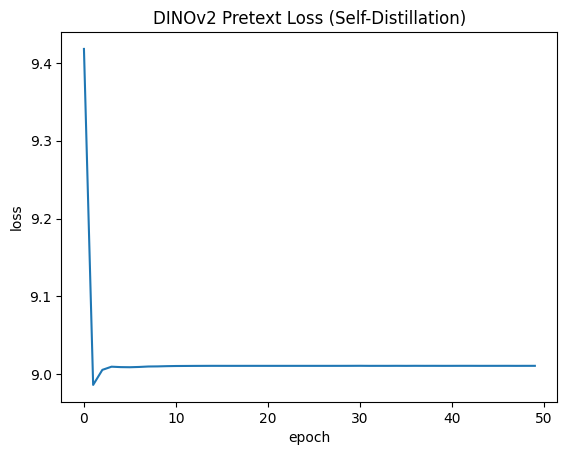

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [6]:
plt.plot(pretext_losses); plt.title("DINOv2 Pretext Loss (Self-Distillation)"); plt.xlabel("epoch"); plt.ylabel("loss")
plt.show()

student.save_pretrained("/kaggle/working/dinov2_encoder")

loss curve and encoder checkpoint 

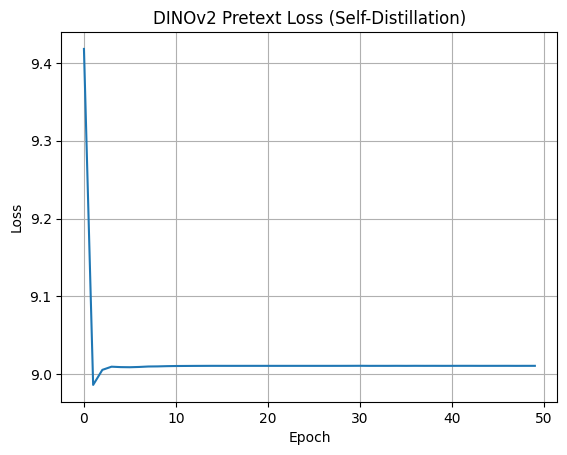

In [7]:
plt.plot(pretext_losses)
plt.title("DINOv2 Pretext Loss (Self-Distillation)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

add segformer b0

In [8]:
from transformers.models.segformer.modeling_segformer import SegformerDecodeHead, SegformerConfig

def build_segformer_decoder(in_channels_list, hidden_size=256, num_classes=NUM_CLASSES):
    cfg = SegformerConfig(num_labels=num_classes, decoder_hidden_size=hidden_size,
                           hidden_sizes=in_channels_list, num_encoder_blocks=len(in_channels_list),
                           reshape_last_stage=True)
    return SegformerDecodeHead(cfg)

class DINOv2SegModel(nn.Module):
    """ViT-S/14 DINOv2 encoder + SegFormer All-MLP head, with token->2D reshape adapter."""
    def __init__(self, vit_encoder, freeze_encoder=False, patch_size=14, img_size=IMG_SIZE):
        super().__init__()
        self.vit = vit_encoder
        self.grid = img_size // patch_size 
        self.embed_dim = self.vit.config.hidden_size 
        self.adapter = nn.ModuleList([nn.Conv2d(self.embed_dim, c, 1) for c in [64,128,320,512]])
        self.decode_head = build_segformer_decoder(in_channels_list=[64,128,320,512])
        if freeze_encoder:
            for p in self.vit.parameters(): p.requires_grad = False

    def forward(self, x):
        tokens = self.vit(pixel_values=x).last_hidden_state[:,1:,:]  
        B, N, C = tokens.shape
        feat_map = tokens.transpose(1,2).reshape(B, C, self.grid, self.grid) 
        stage_feats = [adapt(feat_map) for adapt in self.adapter]
        logits = self.decode_head(stage_feats)
        return F.interpolate(logits, size=x.shape[-2:], mode="bilinear", align_corners=False)

dinov2_encoder = Dinov2Model.from_pretrained("/kaggle/working/dinov2_encoder").to(DEVICE)

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

50 epoch supervised fine tuning

In [9]:
finetune_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE), A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.3), A.RandomRotate90(p=0.3),
    A.Affine(translate_percent=(-0.05,0.05), scale=(0.9,1.1), rotate=(-15,15), p=0.4),
    A.RandomBrightnessContrast(0.15, 0.15, p=0.4),
    A.GaussianBlur((3,5), p=0.2), A.GaussNoise(std_range=(0.05,0.15), p=0.2),
])
test_transform = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE)])

class SegDataset(Dataset):
    def __init__(self, df, transform=None, mask_threshold=MASK_THRESHOLD):
        self.df = df.reset_index(drop=True); self.transform = transform; self.mt = mask_threshold
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.cvtColor(cv2.imread(row["img_path"]), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
        mask = (mask >= self.mt).astype(np.uint8)
        if mask.shape[:2] != img.shape[:2]:
            mask = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
        if self.transform:
            aug = self.transform(image=img, mask=mask); img, mask = aug["image"], aug["mask"]
        img = ((img.astype(np.float32)/255.0) - IMAGENET_MEAN) / IMAGENET_STD
        img = torch.from_numpy(img.transpose(2,0,1)).float()
        return img, torch.from_numpy(mask).long(), row["img_path"]

finetune_ds = SegDataset(val_df, finetune_transform)
test_ds     = SegDataset(test_df, test_transform)

def compute_miou(preds, targets, num_classes=NUM_CLASSES):
    ious = []
    for c in range(num_classes):
        p, t = (preds==c), (targets==c)
        inter, union = (p & t).sum().item(), (p | t).sum().item()
        if union > 0: ious.append(inter/union)
    return float(np.mean(ious)) if ious else 0.0

def dice_loss_fn(logits, targets, eps=1e-6):
    probs = F.softmax(logits, dim=1)[:,1]
    t = targets.float()
    inter = (probs*t).sum((1,2)); union = probs.sum((1,2)) + t.sum((1,2))
    return 1 - ((2*inter+eps)/(union+eps)).mean()

def compute_loss(logits, masks):
    return 0.5*ce_loss_fn(logits, masks) + 0.5*dice_loss_fn(logits, masks)

@torch.no_grad()
def evaluate(loader, forward_fn):
    total_loss, total_miou, n = 0.,0.,0
    for imgs, masks, _ in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        logits = forward_fn(imgs)
        total_loss += ce_loss_fn(logits, masks).item()
        total_miou += compute_miou(logits.argmax(1), masks)
        n += 1
    return total_loss/n, total_miou/n

model = DINOv2SegModel(dinov2_encoder, freeze_encoder=FROZEN_ENCODER).to(DEVICE)

FT_CONFIG = {"model":"DINOv2-ViT-S/14 + SegFormer-Head","frozen_encoder":FROZEN_ENCODER,
             "epochs":50,"batch_size":8,"encoder_lr":1e-5,"decoder_lr":1e-4,
             "optimizer":"AdamW","schedule":"CosineAnnealingLR","input_size":IMG_SIZE,
             "loss":"0.5*CE(weighted)+0.5*Dice"}
print(json.dumps(FT_CONFIG, indent=2))

param_groups = [{"params": model.decode_head.parameters(), "lr": FT_CONFIG["decoder_lr"]},
                {"params": model.adapter.parameters(), "lr": FT_CONFIG["decoder_lr"]}]
if not FROZEN_ENCODER:
    param_groups.append({"params": model.vit.parameters(), "lr": FT_CONFIG["encoder_lr"]})
ft_optimizer = torch.optim.AdamW(param_groups, weight_decay=1e-4)
ft_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(ft_optimizer, T_max=50)

ft_loader = DataLoader(finetune_ds, batch_size=8, shuffle=True, num_workers=2, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=2)

history = {"train_loss":[], "test_loss":[], "test_miou":[]}
best_miou, best_epoch = -1, -1
ft_start = time.time()
for epoch in range(1, 51):
    model.train(); running = 0.; t0=time.time()
    for imgs, masks, _ in ft_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        ft_optimizer.zero_grad()
        loss = compute_loss(model(imgs), masks)
        loss.backward(); ft_optimizer.step()
        running += loss.item()
    ft_scheduler.step()
    train_loss = running/len(ft_loader)
    test_loss, test_miou = evaluate(test_loader, lambda x: model(x))
    history["train_loss"].append(train_loss); history["test_loss"].append(test_loss); history["test_miou"].append(test_miou)
    print(f"[DINOv2-FT] Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
          f"test_loss={test_loss:.4f} | test_mIoU={test_miou:.4f} | time={time.time()-t0:.1f}s")
    if test_miou > best_miou:
        best_miou, best_epoch = test_miou, epoch
        torch.save(model.state_dict(), "/kaggle/working/dinov2_seg_best.pt")

ft_time_min = (time.time()-ft_start)/60
model.load_state_dict(torch.load("/kaggle/working/dinov2_seg_best.pt"))
print(f"\nFine-tuning complete in {ft_time_min:.1f} min. Best test mIoU={best_miou:.4f} at epoch {best_epoch}.")

{
  "model": "DINOv2-ViT-S/14 + SegFormer-Head",
  "frozen_encoder": false,
  "epochs": 50,
  "batch_size": 8,
  "encoder_lr": 1e-05,
  "decoder_lr": 0.0001,
  "optimizer": "AdamW",
  "schedule": "CosineAnnealingLR",
  "input_size": 224,
  "loss": "0.5*CE(weighted)+0.5*Dice"
}
[DINOv2-FT] Epoch 01 | train_loss=0.7094 | test_loss=0.4255 | test_mIoU=0.5248 | time=18.4s
[DINOv2-FT] Epoch 02 | train_loss=0.6248 | test_loss=0.2669 | test_mIoU=0.6456 | time=15.0s
[DINOv2-FT] Epoch 03 | train_loss=0.6005 | test_loss=0.2976 | test_mIoU=0.5741 | time=15.1s
[DINOv2-FT] Epoch 04 | train_loss=0.5779 | test_loss=0.4460 | test_mIoU=0.5402 | time=14.6s
[DINOv2-FT] Epoch 05 | train_loss=0.5682 | test_loss=0.2935 | test_mIoU=0.6008 | time=14.6s
[DINOv2-FT] Epoch 06 | train_loss=0.5570 | test_loss=0.1559 | test_mIoU=0.6849 | time=14.8s
[DINOv2-FT] Epoch 07 | train_loss=0.5537 | test_loss=0.3158 | test_mIoU=0.5494 | time=15.2s
[DINOv2-FT] Epoch 08 | train_loss=0.5397 | test_loss=0.2788 | test_mIoU=0.5871

fine tuning curves

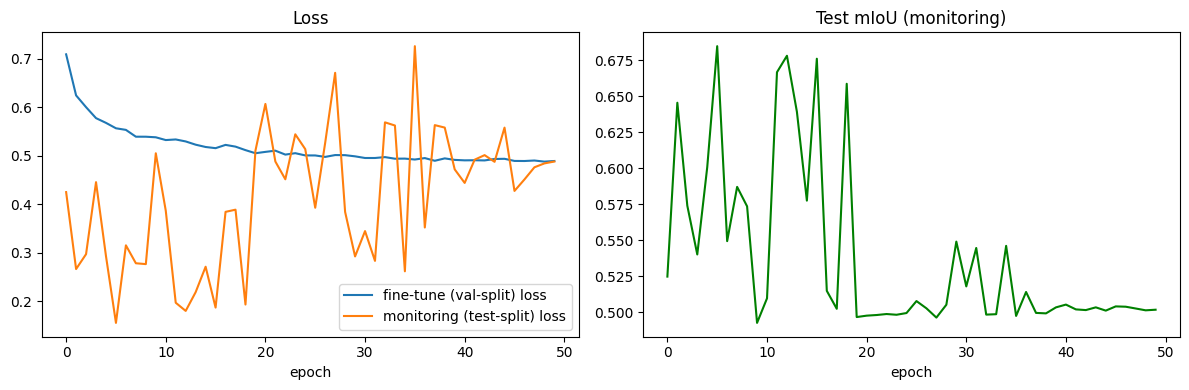

In [10]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].plot(history["train_loss"], label="fine-tune (val-split) loss")
axes[0].plot(history["test_loss"], label="monitoring (test-split) loss"); axes[0].legend()
axes[0].set_xlabel("epoch"); axes[0].set_title("Loss")
axes[1].plot(history["test_miou"], color="green"); axes[1].set_title("Test mIoU (monitoring)")
axes[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()

final test evaluation 

In [11]:
@torch.no_grad()
def full_test_evaluation(loader, forward_fn, num_classes=NUM_CLASSES):
    all_preds, all_targets, per_image_iou = [], [], []
    cm_total = np.zeros((num_classes,num_classes), dtype=np.int64)
    for imgs, masks, paths in loader:
        logits = forward_fn(imgs.to(DEVICE))
        preds = logits.argmax(1).cpu().numpy(); targets = masks.numpy()
        for p, t, path in zip(preds, targets, paths):
            per_image_iou.append((path, compute_miou(torch.tensor(p), torch.tensor(t), num_classes)))
            cm_total += confusion_matrix(t.flatten(), p.flatten(), labels=list(range(num_classes)))
        all_preds.append(preds.flatten()); all_targets.append(targets.flatten())
    all_preds, all_targets = np.concatenate(all_preds), np.concatenate(all_targets)
    per_class_iou, dice_scores = [], []
    for c in range(num_classes):
        p, t = (all_preds==c), (all_targets==c)
        inter, union = (p&t).sum(), (p|t).sum()
        per_class_iou.append(inter/union if union>0 else 0.0)
        dice_scores.append(2*inter/(p.sum()+t.sum()+1e-8))
    miou = float(np.mean(per_class_iou))
    pix_acc = (all_preds==all_targets).mean()
    per_class_acc = [(all_preds[all_targets==c]==c).mean() for c in range(num_classes) if (all_targets==c).sum()>0]
    return {"mIoU": miou, "per_class_iou": [float(x) for x in per_class_iou],
            "overall_pixel_accuracy": float(pix_acc), "mean_pixel_accuracy": float(np.mean(per_class_acc)),
            "mean_dice": float(np.mean(dice_scores)), "dice_per_class": [float(x) for x in dice_scores],
            "confusion_matrix": cm_total.tolist(), "per_image_iou": per_image_iou}

test_results = full_test_evaluation(test_loader, lambda x: model(x))
print(f"DINOv2 test mIoU: {test_results['mIoU']:.4f}  (Part-A SegFormer baseline: 0.8758)")
print(f"Fine-tuned on {len(finetune_ds)} labelled images vs. Part-A's {len(train_df)}")
print(f"Label-efficiency: recovered {test_results['mIoU']/0.8758:.1%} of full-supervision mIoU "
      f"using {len(finetune_ds)/len(train_df):.1%} of the labels")

DINOv2 test mIoU: 0.7633  (Part-A SegFormer baseline: 0.8758)
Fine-tuned on 318 labelled images vs. Part-A's 1035
Label-efficiency: recovered 87.2% of full-supervision mIoU using 30.7% of the labels


confution matrix

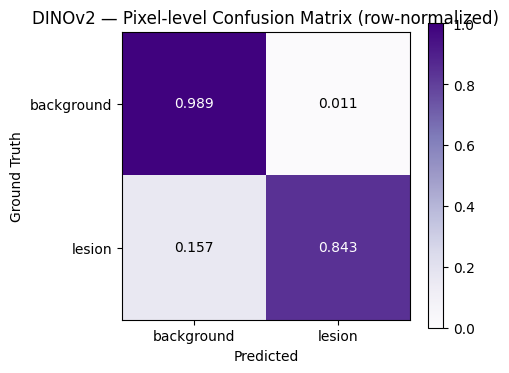

In [12]:
cm = np.array(test_results["confusion_matrix"])
cm_norm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm_norm, cmap="Purples", vmin=0, vmax=1)
ax.set_xticks([0,1]); ax.set_xticklabels(["background","lesion"])
ax.set_yticks([0,1]); ax.set_yticklabels(["background","lesion"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Ground Truth")
ax.set_title("DINOv2 — Pixel-level Confusion Matrix (row-normalized)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm_norm[i,j]:.3f}", ha="center", va="center",
                 color="white" if cm_norm[i,j] > 0.5 else "black")
plt.colorbar(im); plt.tight_layout(); plt.show()

error analysis

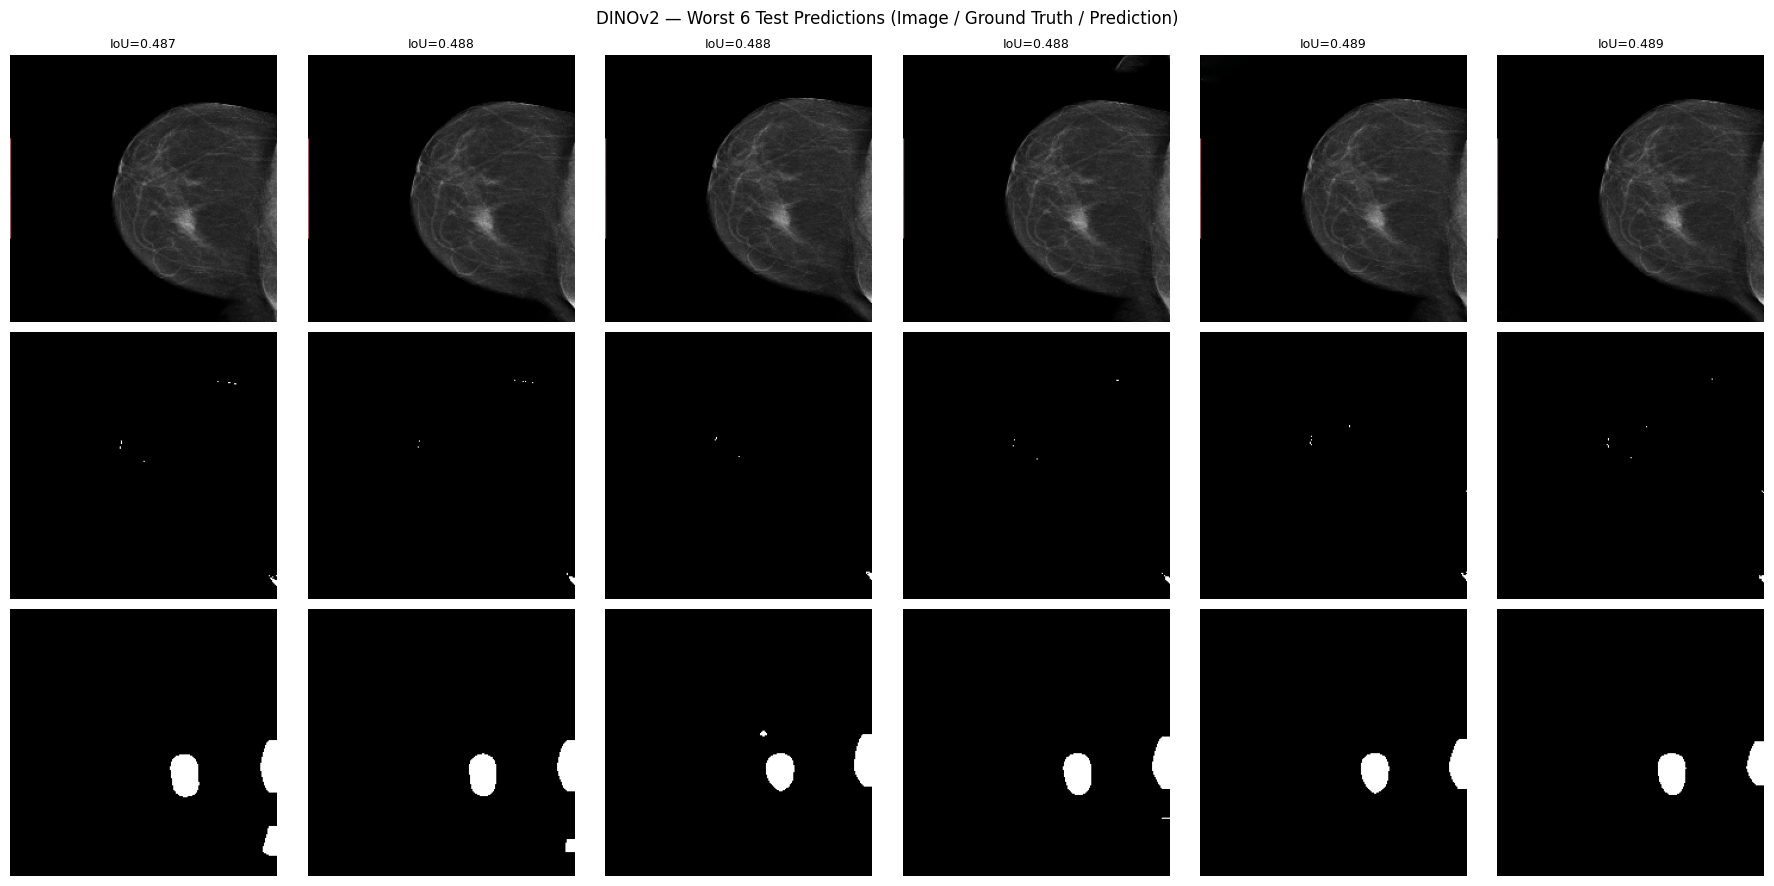

In [13]:
worst = sorted(test_results["per_image_iou"], key=lambda x: x[1])[:6]
fig, axes = plt.subplots(3, 6, figsize=(18,9))
for col, (path, iou) in enumerate(worst):
    row = test_ds.df[test_ds.df["img_path"]==path].iloc[0]
    img = cv2.cvtColor(cv2.imread(row["img_path"]), cv2.COLOR_BGR2RGB)
    gt = (cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE) >= MASK_THRESHOLD).astype(np.uint8)
    img_r = cv2.resize(img, (IMG_SIZE, IMG_SIZE)); gt_r = cv2.resize(gt, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    t = ((img_r.astype(np.float32)/255.)-IMAGENET_MEAN)/IMAGENET_STD
    t = torch.from_numpy(t.transpose(2,0,1)).float().unsqueeze(0).to(DEVICE)
    with torch.no_grad(): pred = model(t).argmax(1).squeeze(0).cpu().numpy()
    axes[0,col].imshow(img_r); axes[0,col].set_title(f"IoU={iou:.3f}", fontsize=9)
    axes[1,col].imshow(gt_r, cmap="gray"); axes[2,col].imshow(pred, cmap="gray")
    for r in range(3): axes[r,col].axis("off")
axes[0,0].set_ylabel("Image"); axes[1,0].set_ylabel("GT"); axes[2,0].set_ylabel("Pred")
plt.suptitle("DINOv2 — Worst 6 Test Predictions (Image / Ground Truth / Prediction)")
plt.tight_layout(); plt.show()

save

In [14]:
def append_results(method_name, summary, results_path="/kaggle/working/results_B.json"):
    all_results = json.load(open(results_path)) if os.path.exists(results_path) else {}
    all_results[method_name] = summary
    json.dump(all_results, open(results_path, "w"), indent=2)
    print(f"Saved {method_name} results.")

append_results("DINOv2", {
    "pretrain_config": PRETRAIN_CONFIG,
    "finetune_config": FT_CONFIG,
    "pretrain_time_min": round(pretrain_time_min, 2),
    "finetune_time_min": round(ft_time_min, 2),
    "best_epoch": best_epoch,
    "test_metrics": test_results,
})

Saved DINOv2 results.
